# Document Classification: Naive Bayes vs KNN
## Using AG News Dataset

### Learning Objectives
- Understand how to convert text data into numerical vectors
- Implement document classification using Naive Bayes and KNN algorithms
- Compare performance and characteristics of both algorithms

### Dataset Information
**AG News Dataset**
- One of the most widely used benchmark datasets for text classification
- Contains news articles from over 2000 news sources
- 4 categories: World, Sports, Business, Science/Technology
- 120,000 training samples, 7,600 test samples

# 📚 Document Classification - Exam Preparation

**🎯 = Important concepts for exam**

Focus on sections marked with 🎯 - these contain key concepts you need to master.

---

## 🎯 Understanding Classification Algorithms

### Naive Bayes vs KNN

**Naive Bayes Classifier**:
- Type: Probabilistic (based on Bayes' theorem)
- **Key Assumption**: All features (words) are **independent** of each other
- Training: Fast (computes probabilities)
- Prediction: Fast
- Memory: Low (stores parameters only)

Mathematical principle:
$$P(w_1, w_2, ..., w_n|\text{class}) = P(w_1|\text{class}) \times P(w_2|\text{class}) \times ...$$

💡 The "naive" assumption is that words are independent - this is the defining characteristic

---

**KNN Classifier**:
- Type: Instance-based (NOT probabilistic)
- Key Assumption: None
- Training: Fast (just stores data)
- Prediction: Slow (compares with all training data)
- Memory: High (stores all training data)

How it works:
1. Stores all training examples
2. For new data: finds k nearest neighbors
3. Classifies by majority vote

💡 KNN is instance-based, not probabilistic - it uses similarity/distance, not probability

---

### 🎯 Distance Metrics: Cosine Similarity

**What cosine similarity measures**:
$$\text{cosine similarity} = \frac{A \cdot B}{||A|| \times ||B||}$$

- Measures the **angle** between two vectors
- Focuses on **orientation** (direction), not **magnitude** (length)
- Range: -1 to 1 (1 = identical direction)

**Why it's good for text**:
- Documents with same content but different lengths have high similarity
- Example:
  - Doc A: "machine learning" (2 words)
  - Doc B: "machine machine learning learning" (4 words, same content)
  - Cosine: HIGH (same direction)
  - Euclidean: LOW (different magnitude)

💡 Cosine is about direction/angle, not distance/length

---

---
## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

---
## 2. Theoretical Background

### 2.1 Naive Bayes Classifier

**Core Principle**
- A probabilistic classifier based on Bayes' theorem
- Assumes all features (words) are independent of each other ("Naive" assumption)

**Mathematical Formula**
$$P(C|X) = \frac{P(X|C) \cdot P(C)}{P(X)}$$

Where:
- $P(C|X)$: Probability of category C given document X
- $P(X|C)$: Likelihood of document X in category C
- $P(C)$: Prior probability of category C

**Advantages**
- Very fast training speed
- Effective even with small datasets
- Performs well in high-dimensional spaces
- Provides probability scores for interpretability

**Disadvantages**
- Independence assumption is unrealistic
- Cannot capture relationships between words

### 2.2 K-Nearest Neighbors (KNN)

**Core Principle**
- A distance-based classification algorithm
- Classifies new data by majority vote of K nearest neighbors

**Distance Metric**
- Cosine similarity is commonly used for text data
$$\text{similarity} = \frac{A \cdot B}{\|A\| \|B\|}$$

**Advantages**
- Intuitive and easy to understand
- No training phase (Lazy Learning)
- Can model non-linear decision boundaries

**Disadvantages**
- Slow prediction time (computes distance to all training data)
- High memory usage
- Performance degrades in high dimensions (curse of dimensionality)
- Sensitive to the choice of K

---
## 3. Load AG News Dataset

In [2]:
# Install datasets library if not already installed
# !pip install datasets

In [3]:
from datasets import load_dataset

# Load AG News dataset
print("Loading AG News dataset...")
dataset = load_dataset('ag_news')

print(f"Dataset loaded successfully")
print(f"Train size: {len(dataset['train'])}")
print(f"Test size: {len(dataset['test'])}")

Loading AG News dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset loaded successfully
Train size: 120000
Test size: 7600


In [4]:
# Convert to pandas DataFrame for easier manipulation
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

# Map label numbers to category names
label_names = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
train_df['category'] = train_df['label'].map(label_names)
test_df['category'] = test_df['label'].map(label_names)

print("\nDataset structure:")
print(train_df.head())


Dataset structure:
                                                text  label  category
0  Wall St. Bears Claw Back Into the Black (Reute...      2  Business
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2  Business
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2  Business
3  Iraq Halts Oil Exports from Main Southern Pipe...      2  Business
4  Oil prices soar to all-time record, posing new...      2  Business


In [5]:
# For practical training time, we'll use a subset of the data
# Feel free to increase this for better performance
TRAIN_SIZE = 10000
TEST_SIZE = 2000

train_sample = train_df.sample(n=TRAIN_SIZE, random_state=42)
test_sample = test_df.sample(n=TEST_SIZE, random_state=42)

print(f"Using {TRAIN_SIZE} training samples and {TEST_SIZE} test samples")
print(f"\nCategory distribution in training set:")
print(train_sample['category'].value_counts())

Using 10000 training samples and 2000 test samples

Category distribution in training set:
category
Sports      2549
Sci/Tech    2515
Business    2471
World       2465
Name: count, dtype: int64


---
## 4. Exploratory Data Analysis

In [6]:
# Analyze text length
train_sample['word_count'] = train_sample['text'].str.split().str.len()

print("Text length statistics:")
print(train_sample['word_count'].describe())

Text length statistics:
count    10000.000000
mean        37.775500
std         10.282309
min          9.000000
25%         32.000000
50%         37.000000
75%         43.000000
max        150.000000
Name: word_count, dtype: float64


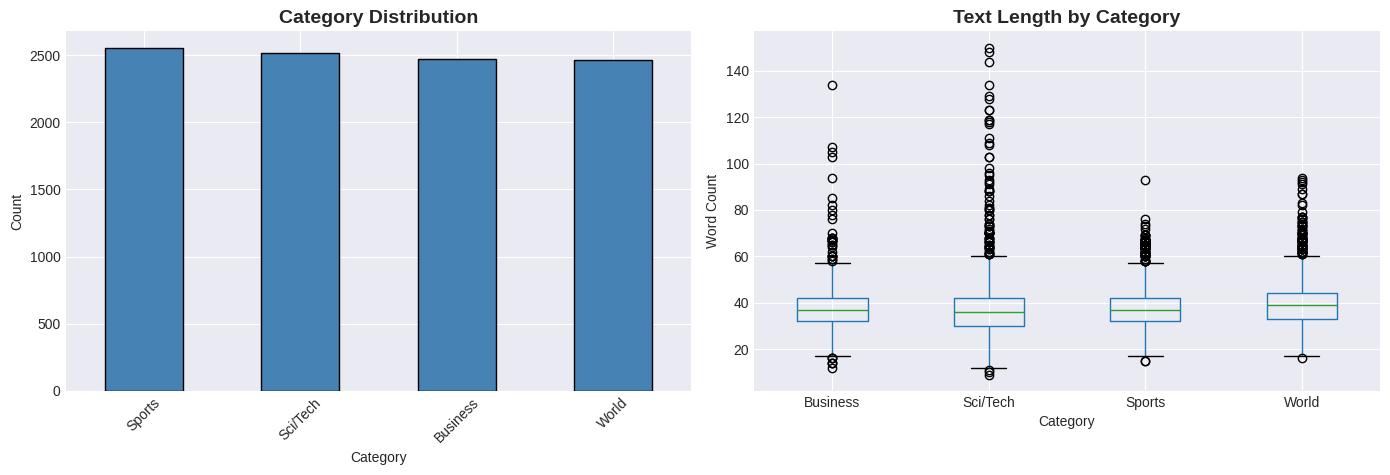

In [7]:
# Visualize category distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category distribution
train_sample['category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Text length distribution by category
train_sample.boxplot(column='word_count', by='category', ax=axes[1])
axes[1].set_title('Text Length by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.show()

---
## 5. Prepare Train and Test Sets

In [8]:
# Extract features and labels
X_train = train_sample['text']
y_train = train_sample['category']
X_test = test_sample['text']
y_test = test_sample['category']

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 10000
Test samples: 2000


## 6. Text Vectorization with TF-IDF

🎯 **Key Concept**: TF-IDF Parameters

### Understanding TfidfVectorizer Parameters

```python
TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # 🎯 Important parameter
    min_df=2,            # 🎯 Important parameter
    max_df=0.8,
    stop_words='english'
)
```

**🎯 ngram_range=(1, 2)**:
- Creates **unigrams** (single words) AND **bigrams** (two consecutive words)
- Example: "machine learning is great"
  - Unigrams: ["machine", "learning", "is", "great"]
  - Bigrams: ["machine learning", "learning is", "is great"]
- **Purpose**: Captures both individual words AND common phrases
- **Benefit**: Better feature representation ("New York" as phrase vs separate words)

**🎯 min_df=2**:
- Removes words that appear in **fewer than 2 documents**
- **Purpose**: Filters out extremely rare words
- **Removes**: Typos, document-specific terms
- **Benefit**: Reduces noise, improves generalization
- Example: "asdfgh" (typo) in 1 doc → removed

---

### 🎯 Critical Concept: fit_transform() vs transform()

**The correct pattern**:
```python
# On training data: fit_transform()
X_train = vectorizer.fit_transform(X_train)

# On test data: transform()
X_test = vectorizer.transform(X_test)
```

**Why this matters**:

**fit_transform()** (training data only):
- **Learns** the vocabulary from the data
- **Learns** the IDF (inverse document frequency) values
- **Transforms** the data into TF-IDF features

**transform()** (test data):
- Uses the vocabulary **already learned** from training
- Uses the IDF values **already learned** from training
- Only **transforms** the data (no learning)

**💡 Why not use fit_transform() on test data?**

**Reason**: Prevents data leakage
- The model should NOT see test data during training
- Test data should be completely "unseen"

**What happens if you use fit_transform() on both?**
- Creates **different vocabularies** for train and test
- Creates **different IDF values** for train and test
- Results in **incompatible feature spaces** (can't compare)
- Causes **data leakage** (test info influences model)
- Leads to **invalid evaluation** (overly optimistic results)

**Real-world analogy**:
- Training: Teacher decides which 1000 words students should know
- Test: Students are tested on those same 1000 words
- Wrong: Letting students pick different words for the test!

---

### 🎯 Complete Code Pattern: Training with TF-IDF

This is the standard workflow you need to understand:

```python
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

# Step 1: Split data
X_train, X_test, y_train, y_test = train_test_split(
    reviews, categories,
    test_size=0.2,  # 💡 Important parameter
    random_state=42
)

# Step 2: TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8)

X_train_tfidf = tfidf.fit_transform(X_train)  # 💡 Learn + transform
X_test_tfidf = tfidf.transform(X_test)        # 💡 Transform only

# Step 3: Train classifier
nb_clf = MultinomialNB(alpha=0.01)
nb_clf.fit(X_train_tfidf, y_train)
```

**Key Points to Remember**:
1. **test_size**: Proportion of data for testing (0.2 = 20%)
2. **fit_transform()**: Use on training data (learns vocabulary)
3. **transform()**: Use on test data (uses learned vocabulary)

---


In [9]:
# 🎯 Important Code Pattern: TF-IDF Vectorization
# Study this pattern - it's a common workflow

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize vectorizer with important parameters
vectorizer_tfidf = TfidfVectorizer(
    max_features=5000,      # Keep top 5000 features
    ngram_range=(1, 2),     # 💡 Unigrams + Bigrams
    min_df=2,               # 💡 Remove if in < 2 documents
    max_df=0.8,             # Remove if in > 80% documents
    stop_words='english'    # Remove common English words
)

# 🎯 CRITICAL: Different methods for train vs test

# Training data: fit_transform (learn + transform)
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)

# Test data: transform only (use learned vocabulary)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

print(f'Training shape: {X_train_tfidf.shape}')
print(f'Test shape: {X_test_tfidf.shape}')
print(f'Vocabulary size: {len(vectorizer_tfidf.vocabulary_)}')

Training shape: (10000, 5000)
Test shape: (2000, 5000)
Vocabulary size: 5000


In [10]:
# Count Vectorizer for comparison
vectorizer_count = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8,
    stop_words='english'
)

X_train_count = vectorizer_count.fit_transform(X_train)
X_test_count = vectorizer_count.transform(X_test)

print(f"Count vectorization completed")
print(f"Shape: {X_train_count.shape}")

Count vectorization completed
Shape: (10000, 5000)


---
## 7. Naive Bayes Model

In [11]:
# 🎯 Complete Pipeline: Naive Bayes with TF-IDF
# This is the standard pattern you should know

# Naive Bayes with TF-IDF
print("Training Naive Bayes with TF-IDF...")
nb_tfidf = MultinomialNB(alpha=0.1)

start = time()
nb_tfidf.fit(X_train_tfidf, y_train)
train_time_nb_tfidf = time() - start

start = time()
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
predict_time_nb_tfidf = time() - start

acc_nb_tfidf = accuracy_score(y_test, y_pred_nb_tfidf)
f1_nb_tfidf = f1_score(y_test, y_pred_nb_tfidf, average='weighted')

print(f"Training time: {train_time_nb_tfidf:.4f}s")
print(f"Prediction time: {predict_time_nb_tfidf:.4f}s")
print(f"Accuracy: {acc_nb_tfidf:.4f} ({acc_nb_tfidf*100:.2f}%)")
print(f"F1-Score: {f1_nb_tfidf:.4f}")

Training Naive Bayes with TF-IDF...
Training time: 0.0214s
Prediction time: 0.0007s
Accuracy: 0.8775 (87.75%)
F1-Score: 0.8769


In [12]:
# Naive Bayes with Count Vectorizer
print("Training Naive Bayes with Count Vectorizer...")
nb_count = MultinomialNB(alpha=0.1)

start = time()
nb_count.fit(X_train_count, y_train)
train_time_nb_count = time() - start

start = time()
y_pred_nb_count = nb_count.predict(X_test_count)
predict_time_nb_count = time() - start

acc_nb_count = accuracy_score(y_test, y_pred_nb_count)
f1_nb_count = f1_score(y_test, y_pred_nb_count, average='weighted')

print(f"Training time: {train_time_nb_count:.4f}s")
print(f"Prediction time: {predict_time_nb_count:.4f}s")
print(f"Accuracy: {acc_nb_count:.4f} ({acc_nb_count*100:.2f}%)")
print(f"F1-Score: {f1_nb_count:.4f}")

Training Naive Bayes with Count Vectorizer...
Training time: 0.0218s
Prediction time: 0.0006s
Accuracy: 0.8735 (87.35%)
F1-Score: 0.8727


## 8. KNN Classification

🎯 **Key Concept**: KNN Implementation Pattern

### Important Parameters for KNN:

**n_neighbors**: The 'k' value (how many neighbors to consider)
- Typical values: 3, 5, 7
- Smaller k: more sensitive to noise
- Larger k: smoother decision boundaries

**metric**: Distance/similarity measure
- 'cosine': cosine similarity (good for text)
- 'euclidean': Euclidean distance
- 'manhattan': Manhattan distance

**n_jobs**: Number of CPU cores to use
- -1: use all available cores (fastest)

---

In [19]:
# 🎯 Important Code Pattern: KNN Implementation
# Study this pattern - common in text classification

import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

k_values = [3, 5, 7]
knn_results = {}

for k in k_values:
    print(f'\nTraining KNN with k={k}')

    # 🎯 Initialize KNN classifier
    # Three important parameters:
    knn = KNeighborsClassifier(
        n_neighbors=k,      # 💡 The k value
        metric='cosine',    # 💡 Use cosine similarity for text
        n_jobs=-1           # Use all CPU cores
    )

    # Train the model (measure time)
    start_time = time.time()
    knn.fit(X_train_tfidf, y_train)
    train_time = time.time() - start_time

    # Make predictions (measure time)
    start_time = time.time()
    y_pred = knn.predict(X_test_tfidf)
    predict_time = time.time() - start_time

    # 🎯 Evaluate with accuracy_score
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store all results including time measurements
    knn_results[k] = {
        'accuracy': acc,
        'f1': f1,
        'train_time': train_time,
        'predict_time': predict_time
    }

    print(f'Accuracy: {acc:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'Train Time: {train_time:.4f}s')
    print(f'Predict Time: {predict_time:.4f}s')

# 💡 Remember:
# - n_neighbors: the k value
# - metric='cosine': for text data
# - accuracy_score(y_true, y_pred): to calculate accuracy


Training KNN with k=3
Accuracy: 0.8205
F1 Score: 0.8212
Train Time: 0.0202s
Predict Time: 0.7498s

Training KNN with k=5
Accuracy: 0.8305
F1 Score: 0.8305
Train Time: 0.0141s
Predict Time: 1.3129s

Training KNN with k=7
Accuracy: 0.8400
F1 Score: 0.8397
Train Time: 0.0351s
Predict Time: 0.7146s


---
## 9. Model Comparison

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Create comparison dataframe
results_data = {
    'Model': ['NB + TF-IDF', 'NB + Count', 'KNN(k=3)', 'KNN(k=5)', 'KNN(k=7)'],
    'Accuracy': [
        acc_nb_tfidf,
        acc_nb_count,
        knn_results[3]['accuracy'],
        knn_results[5]['accuracy'],
        knn_results[7]['accuracy']
    ],
    'F1-Score': [
        f1_nb_tfidf,
        f1_nb_count,
        knn_results[3]['f1'],
        knn_results[5]['f1'],
        knn_results[7]['f1']
    ],
    'Train Time (s)': [
        train_time_nb_tfidf,
        train_time_nb_count,
        knn_results[3]['train_time'],
        knn_results[5]['train_time'],
        knn_results[7]['train_time']
    ],
    'Predict Time (s)': [
        predict_time_nb_tfidf,
        predict_time_nb_count,
        knn_results[3]['predict_time'],
        knn_results[5]['predict_time'],
        knn_results[7]['predict_time']
    ]
}

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values('Accuracy', ascending=False)
print("\nPerformance Comparison:")
print(results_df.to_string(index=False))


Performance Comparison:
      Model  Accuracy  F1-Score  Train Time (s)  Predict Time (s)
NB + TF-IDF    0.8775  0.876915        0.021414          0.000683
 NB + Count    0.8735  0.872731        0.021795          0.000604
   KNN(k=7)    0.8400  0.839699        0.035125          0.714605
   KNN(k=5)    0.8305  0.830506        0.014145          1.312927
   KNN(k=3)    0.8205  0.821185        0.020230          0.749808


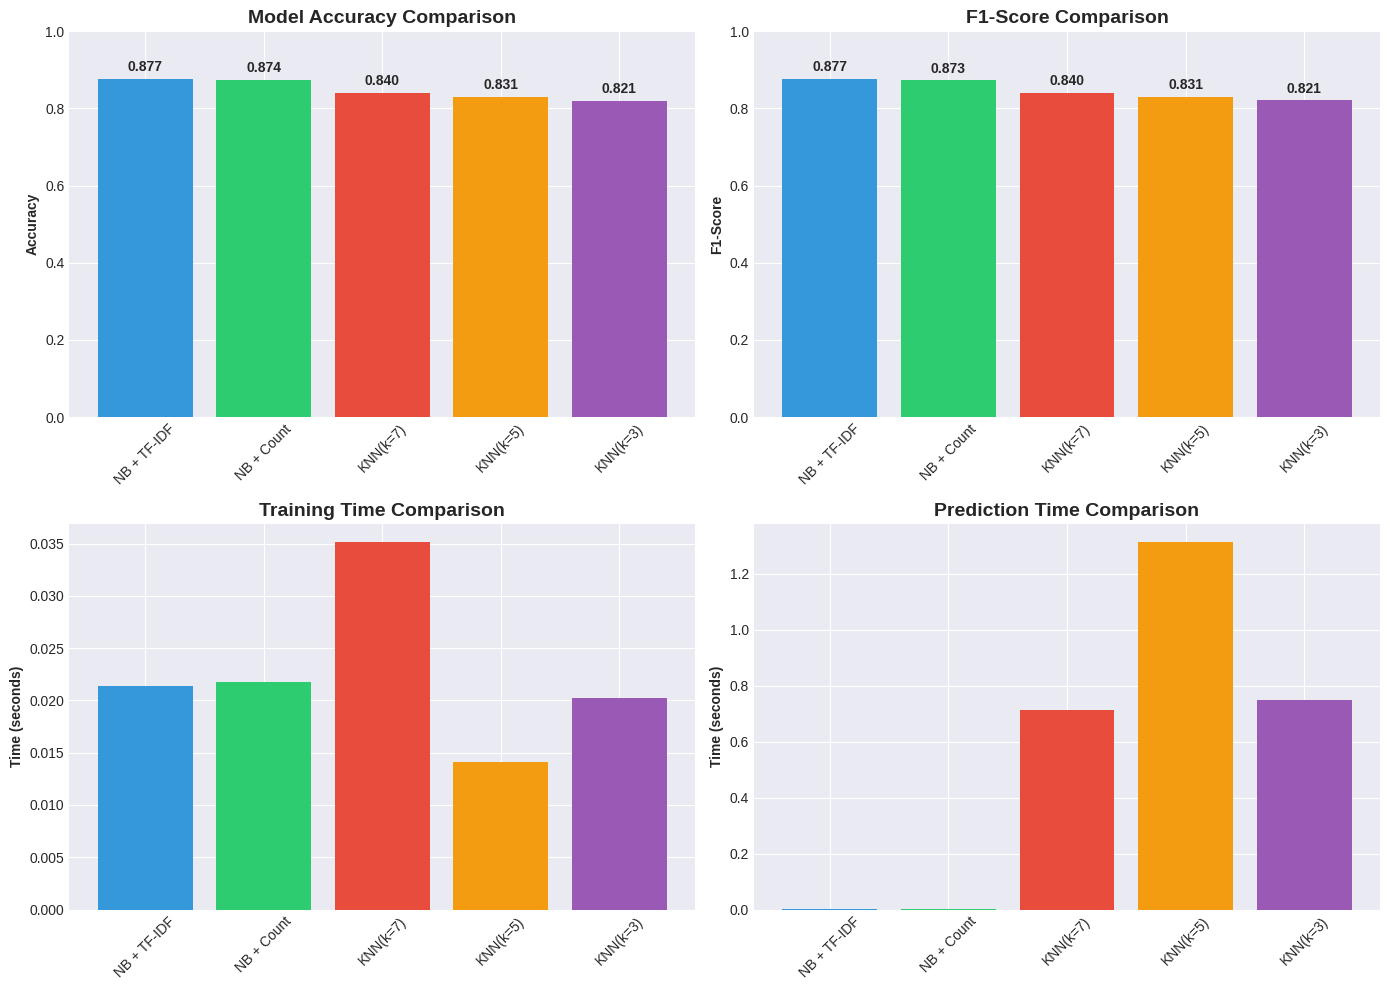

In [21]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
axes[0, 0].bar(results_df['Model'], results_df['Accuracy'], color=colors)
axes[0, 0].set_ylabel('Accuracy', fontweight='bold')
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['Accuracy']):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# F1-Score comparison
axes[0, 1].bar(results_df['Model'], results_df['F1-Score'], color=colors)
axes[0, 1].set_ylabel('F1-Score', fontweight='bold')
axes[0, 1].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['F1-Score']):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Training time comparison
axes[1, 0].bar(results_df['Model'], results_df['Train Time (s)'], color=colors)
axes[1, 0].set_ylabel('Time (seconds)', fontweight='bold')
axes[1, 0].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# Prediction time comparison
axes[1, 1].bar(results_df['Model'], results_df['Predict Time (s)'], color=colors)
axes[1, 1].set_ylabel('Time (seconds)', fontweight='bold')
axes[1, 1].set_title('Prediction Time Comparison', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 10. Detailed Performance Analysis

In [22]:
# Classification report for best model
print("Classification Report (Naive Bayes + TF-IDF):")
print(classification_report(y_test, y_pred_nb_tfidf))

Classification Report (Naive Bayes + TF-IDF):
              precision    recall  f1-score   support

    Business       0.85      0.80      0.82       474
    Sci/Tech       0.84      0.87      0.86       529
      Sports       0.93      0.96      0.95       504
       World       0.88      0.88      0.88       493

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000



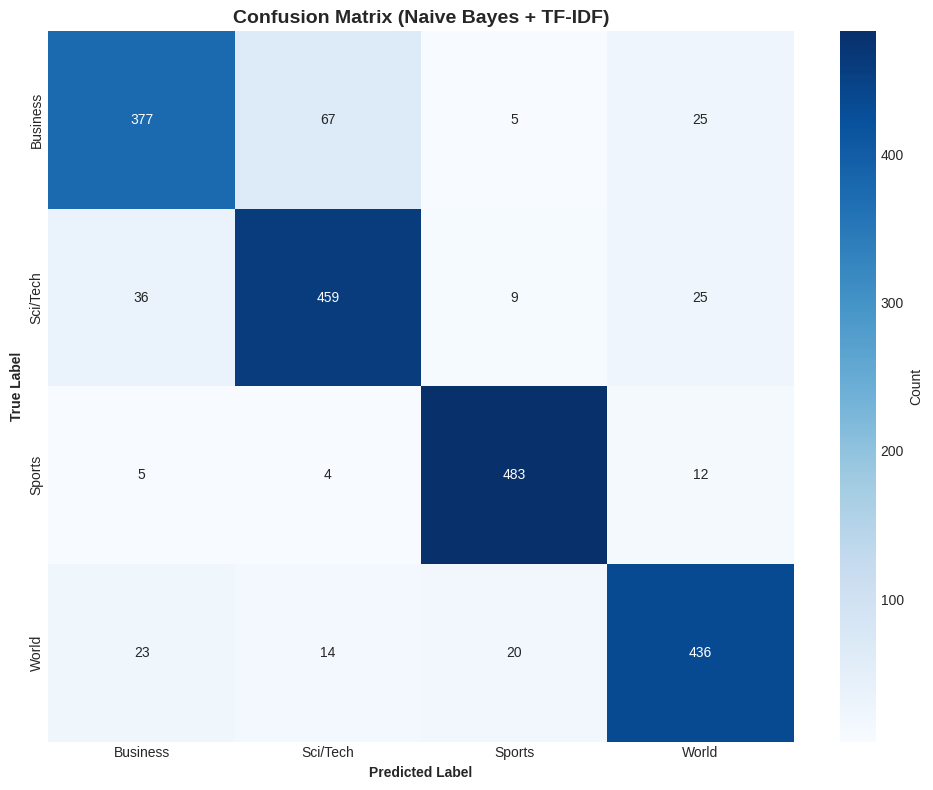

In [23]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_nb_tfidf)
categories = sorted(train_sample['category'].unique())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix (Naive Bayes + TF-IDF)', fontweight='bold', fontsize=14)
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# Analyze misclassifications
misclassified_mask = y_test != y_pred_nb_tfidf
misclassified = test_sample[misclassified_mask].copy()
misclassified['predicted'] = y_pred_nb_tfidf[misclassified_mask]

print(f"\nMisclassified samples: {len(misclassified)} out of {len(y_test)} ({len(misclassified)/len(y_test)*100:.1f}%)")
print("\nExamples of misclassifications:")
for idx, row in misclassified.head(3).iterrows():
    print(f"\nText: {row['text'][:100]}...")
    print(f"True: {row['category']} | Predicted: {row['predicted']}")


Misclassified samples: 245 out of 2000 (12.2%)

Examples of misclassifications:

Text: Paris Tourists Search for Key to 'Da Vinci Code' (Reuters) Reuters - A funny thing happened on the w...
True: World | Predicted: Sci/Tech

Text: Chavez rejects CD as opposition Venezuela #39;s President Hugo Chavez has announced that he will no ...
True: Business | Predicted: World

Text: Selling Houston Warts and All, Especially Warts Descriptions of urban afflictions and images of gian...
True: Business | Predicted: Sci/Tech


---
## 11. Cross-Validation

In [25]:
# 5-Fold Cross-Validation
print("Performing 5-fold cross-validation...\n")

# Prepare data for CV
X_all = vectorizer_tfidf.fit_transform(train_sample['text'])
y_all = train_sample['category']

# Naive Bayes CV
cv_scores_nb = cross_val_score(nb_tfidf, X_all, y_all, cv=5, scoring='accuracy')
print(f"Naive Bayes CV Scores: {cv_scores_nb}")
print(f"Mean: {cv_scores_nb.mean():.4f} (+/- {cv_scores_nb.std():.4f})")

# KNN CV (k=5)
knn_5 = KNeighborsClassifier(n_neighbors=5, metric='cosine', n_jobs=-1)
cv_scores_knn = cross_val_score(knn_5, X_all, y_all, cv=5, scoring='accuracy')
print(f"\nKNN (k=5) CV Scores: {cv_scores_knn}")
print(f"Mean: {cv_scores_knn.mean():.4f} (+/- {cv_scores_knn.std():.4f})")

Performing 5-fold cross-validation...

Naive Bayes CV Scores: [0.8975 0.8905 0.889  0.8895 0.8885]
Mean: 0.8910 (+/- 0.0033)

KNN (k=5) CV Scores: [0.838  0.828  0.8455 0.8305 0.8365]
Mean: 0.8357 (+/- 0.0061)


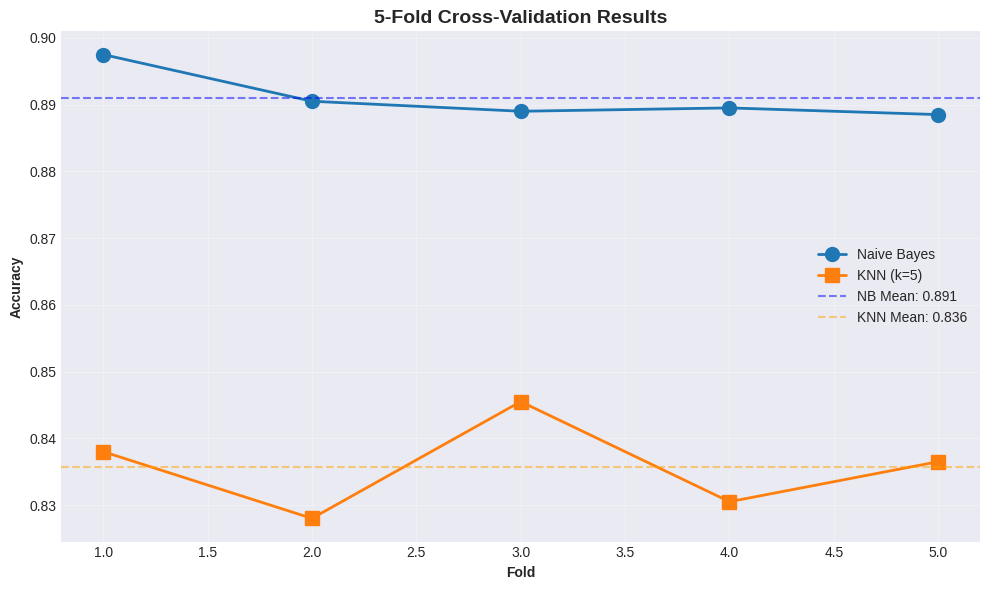

In [26]:
# Visualize CV results
fig, ax = plt.subplots(figsize=(10, 6))

folds = range(1, 6)
ax.plot(folds, cv_scores_nb, 'o-', linewidth=2, markersize=10, label='Naive Bayes')
ax.plot(folds, cv_scores_knn, 's-', linewidth=2, markersize=10, label='KNN (k=5)')

ax.axhline(y=cv_scores_nb.mean(), color='blue', linestyle='--', alpha=0.5, label=f'NB Mean: {cv_scores_nb.mean():.3f}')
ax.axhline(y=cv_scores_knn.mean(), color='orange', linestyle='--', alpha=0.5, label=f'KNN Mean: {cv_scores_knn.mean():.3f}')

ax.set_xlabel('Fold', fontweight='bold')
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 12. Predict New Documents

In [27]:
# Example news articles for prediction
new_articles = [
    "Apple announces new iPhone with advanced AI capabilities and improved camera system.",
    "The stock market reached new highs today as investors showed confidence in economic recovery.",
    "Scientists discover a new planet in the habitable zone of a nearby star system.",
    "The national team won the championship after an exciting final match against their rivals."
]

# Vectorize new articles
new_articles_vec = vectorizer_tfidf.transform(new_articles)

# Predict with Naive Bayes
predictions = nb_tfidf.predict(new_articles_vec)
probabilities = nb_tfidf.predict_proba(new_articles_vec)

print("Prediction Results:\n")
for i, article in enumerate(new_articles):
    print(f"Article {i+1}: {article}")
    print(f"Predicted Category: {predictions[i]}")
    print("Probabilities:")
    for j, category in enumerate(nb_tfidf.classes_):
        print(f"  {category}: {probabilities[i][j]:.4f} ({probabilities[i][j]*100:.1f}%)")
    print()

Prediction Results:

Article 1: Apple announces new iPhone with advanced AI capabilities and improved camera system.
Predicted Category: Sci/Tech
Probabilities:
  Business: 0.0552 (5.5%)
  Sci/Tech: 0.9315 (93.1%)
  Sports: 0.0078 (0.8%)
  World: 0.0056 (0.6%)

Article 2: The stock market reached new highs today as investors showed confidence in economic recovery.
Predicted Category: Business
Probabilities:
  Business: 0.9957 (99.6%)
  Sci/Tech: 0.0014 (0.1%)
  Sports: 0.0002 (0.0%)
  World: 0.0027 (0.3%)

Article 3: Scientists discover a new planet in the habitable zone of a nearby star system.
Predicted Category: Sci/Tech
Probabilities:
  Business: 0.0445 (4.4%)
  Sci/Tech: 0.8360 (83.6%)
  Sports: 0.0319 (3.2%)
  World: 0.0877 (8.8%)

Article 4: The national team won the championship after an exciting final match against their rivals.
Predicted Category: Sports
Probabilities:
  Business: 0.0020 (0.2%)
  Sci/Tech: 0.0044 (0.4%)
  Sports: 0.9872 (98.7%)
  World: 0.0063 (0.6%)

